In [201]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates


In [202]:
# Ticker
symbols = ["ETH"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-06-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 6)

# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3
adx_threshold = 25

#
k = KrakenHistoricalData()
s = Signals()

df_multi = k.get_ohlcv_df(symbols, interval=interval)
print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                                   ETH                                         \
                                  open         high          low        close   
2024-01-01 00:00:00+00:00  2281.939941  2305.000000  2272.199951  2273.659912   
2024-01-01 04:00:00+00:00  2273.649902  2287.000000  2266.639893  2284.520020   
2024-01-01 08:00:00+00:00  2284.510010  2303.429932  2281.000000  2303.429932   
2024-01-01 12:00:00+00:00  2303.429932  2316.010010  2295.939941  2314.320068   
2024-01-01 16:00:00+00:00  2314.330078  2340.409912  2307.389893  2338.189941   

                                                           
                                 volume trades base quote  
2024-01-01 00:00:00+00:00  1.352582e+10   1159  ETH   USD  
2024-01-01 04:00:00+00:00  1.597955e+10    803  ETH   USD  
2024-01-01 08:00:00+00:00  3.081944e+09    572  ETH   USD  
2024-01-01 12:00:00+00:00  7.464672e+09   1007  ETH   USD  
2024-01-01 16:00:00+00:00  1.715342e+10   1634  ETH   USD  

MultiIndex 

In [203]:
# Signals
signals = df.copy()
# moving average
# ma = pta.ohlc4(df['open'],df['high'],df['low'],df['close'])
ma = pta.zlma(df['close'], 10)

# Calculate technical indicators
signals['rsi'] = pta.rsi(df['close'])

# adx > 25 strong trend
adx = pta.adx(df['high'], df['low'], df['close'])


# Entry: SAR Signal
psar = pta.psar(df['high'],
                df['low'],
                close=df['close'])
print(f"\nSAR:")

signals['sar'] = psar.iloc[:, 0]
signals['sar_s'] = np.where(signals['sar'] > 0, True, False)

print(signals[['sar', 'sar_s']].tail())  # Entry Signals


print(f"\nADX:")
print(tabulate(adx.tail(), headers="keys", tablefmt="github"))
signals['adx'] = adx.iloc[:, 1]
signals['adx_s'] = np.where(signals['adx'] > adx_threshold, True, False)

# Exit: Chandlier Exit uses ATR
signals['atr'] = pta.atr(df['high'], df['low'], df['close'])
ce = pta.chandelier_exit(df['high'],
                         df['low'],
                         df['close'],
                         multiplier=atr_multiplier, )

signals['ce_l'] = np.where(ce.iloc[:, 2] > 0, ce.iloc[:, 0], np.nan)
signals['ce_sh'] = np.where(ce.iloc[:, 2] < 0, ce.iloc[:, 1], np.nan)
signals['ce_exit'] = np.where(ce.iloc[:, 2] == 1, False, True)
print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].tail(50))

# entry
print(f"\nEntry Signals:")
# Have ADX strength, and sar is a buy and ce is not an exit
entry_series = signals['adx_s'] & signals['sar_s'] & ~signals['ce_exit']
entry_rise = entry_series & (~entry_series.shift(1, fill_value=False))
print(entry_rise.tail(50))

print(f"\nExit Signals:")
exit_series = signals['ce_exit']
print(exit_series.tail(20))
exit_rise = exit_series & (~exit_series.shift(1, fill_value=False))
print(exit_rise.tail(20))



SAR:
                                   sar  sar_s
2025-06-29 08:00:00+00:00  2380.389893   True
2025-06-29 12:00:00+00:00  2382.054893   True
2025-06-29 16:00:00+00:00  2383.686593   True
2025-06-29 20:00:00+00:00  2385.285659   True
2025-06-30 00:00:00+00:00  2390.825033   True

ADX:
|                           |   ADX_14 |   ADXR_14_2 |   DMP_14 |   DMN_14 |
|---------------------------|----------|-------------|----------|----------|
| 2025-06-29 08:00:00+00:00 |  18.2674 |     18.9574 |  89.6082 |  94.3852 |
| 2025-06-29 12:00:00+00:00 |  17.2935 |     18.3832 |  83.2076 |  91.2933 |
| 2025-06-29 16:00:00+00:00 |  16.559  |     17.4132 |  77.2642 |  88.9125 |
| 2025-06-29 20:00:00+00:00 |  17.4968 |     17.3952 | 152.285  |  82.5616 |
| 2025-06-30 00:00:00+00:00 |  18.3677 |     17.4633 | 141.408  |  76.6643 |

Chandelier Exit:
                                  ce_l        ce_sh  ce_exit
2025-06-21 20:00:00+00:00          NaN  2381.505986     True
2025-06-22 00:00:00+00:00        

In [204]:
# filter entries and exits, one for one entry/exit

in_pos = False
filtered_entry = pd.Series(False, index=signals.index)
filtered_exit = pd.Series(False, index=signals.index)

for ts in signals.index:
    if not in_pos and entry_rise.loc[ts]:
        filtered_entry.loc[ts] = True
        in_pos = True
    elif in_pos and exit_rise.loc[ts]:
        filtered_exit.loc[ts] = True
        in_pos = False
    # elif in_pos and exit_series.loc[ts]:
    #     filtered_exit.loc[ts] = True
    #     in_pos = False
# filtered_exit = filtered_entry.shift(-1, fill_value=False)
i_start = 40*6
i_end = 50*6
entry_concat = pd.concat([entry_series.iloc[i_start:i_end],filtered_entry.iloc[i_start:i_end]],axis=1)
exit_concat = pd.concat([exit_series.iloc[i_start:i_end],filtered_exit.iloc[i_start:i_end]],axis=1)

print(f"\nFiltered Entry/Exit Signals:")
print(pd.concat([entry_concat,exit_concat],axis=1))

print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].iloc[i_start:i_end])


Filtered Entry/Exit Signals:
                               0      1  ce_exit      0
2025-02-10 00:00:00+00:00  False  False     True  False
2025-02-10 04:00:00+00:00  False  False     True  False
2025-02-10 08:00:00+00:00  False  False     True  False
2025-02-10 12:00:00+00:00  False  False     True  False
2025-02-10 16:00:00+00:00  False  False     True  False
2025-02-10 20:00:00+00:00  False  False     True  False
2025-02-11 00:00:00+00:00  False  False     True  False
2025-02-11 04:00:00+00:00   True   True    False  False
2025-02-11 08:00:00+00:00   True  False    False  False
2025-02-11 12:00:00+00:00   True  False    False  False
2025-02-11 16:00:00+00:00   True  False    False  False
2025-02-11 20:00:00+00:00   True  False    False  False
2025-02-12 00:00:00+00:00   True  False    False  False
2025-02-12 04:00:00+00:00   True  False    False  False
2025-02-12 08:00:00+00:00   True  False    False  False
2025-02-12 12:00:00+00:00  False  False    False  False
2025-02-12 16:00:0

In [205]:
entry_times = list(filtered_entry[filtered_entry].index)
exit_times = list(filtered_exit[filtered_exit].index)

# 2) Pair entries with the next exit after each entry
pairs = []
j = 0
for et in entry_times:
    while j < len(exit_times) and exit_times[j] <= et:
        j += 1
    if j < len(exit_times):
        pairs.append((et, exit_times[j]))
        j += 1



In [206]:
##  Boolean where in position
y1_arr = signals['close'].values
in_position = pd.Series(pd.NA, index=filtered_entry.index, dtype="boolean")
in_position[filtered_entry] = filtered_entry[filtered_entry]
in_position[filtered_exit] = ~filtered_exit[filtered_exit]
in_position.ffill(inplace=True)
y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

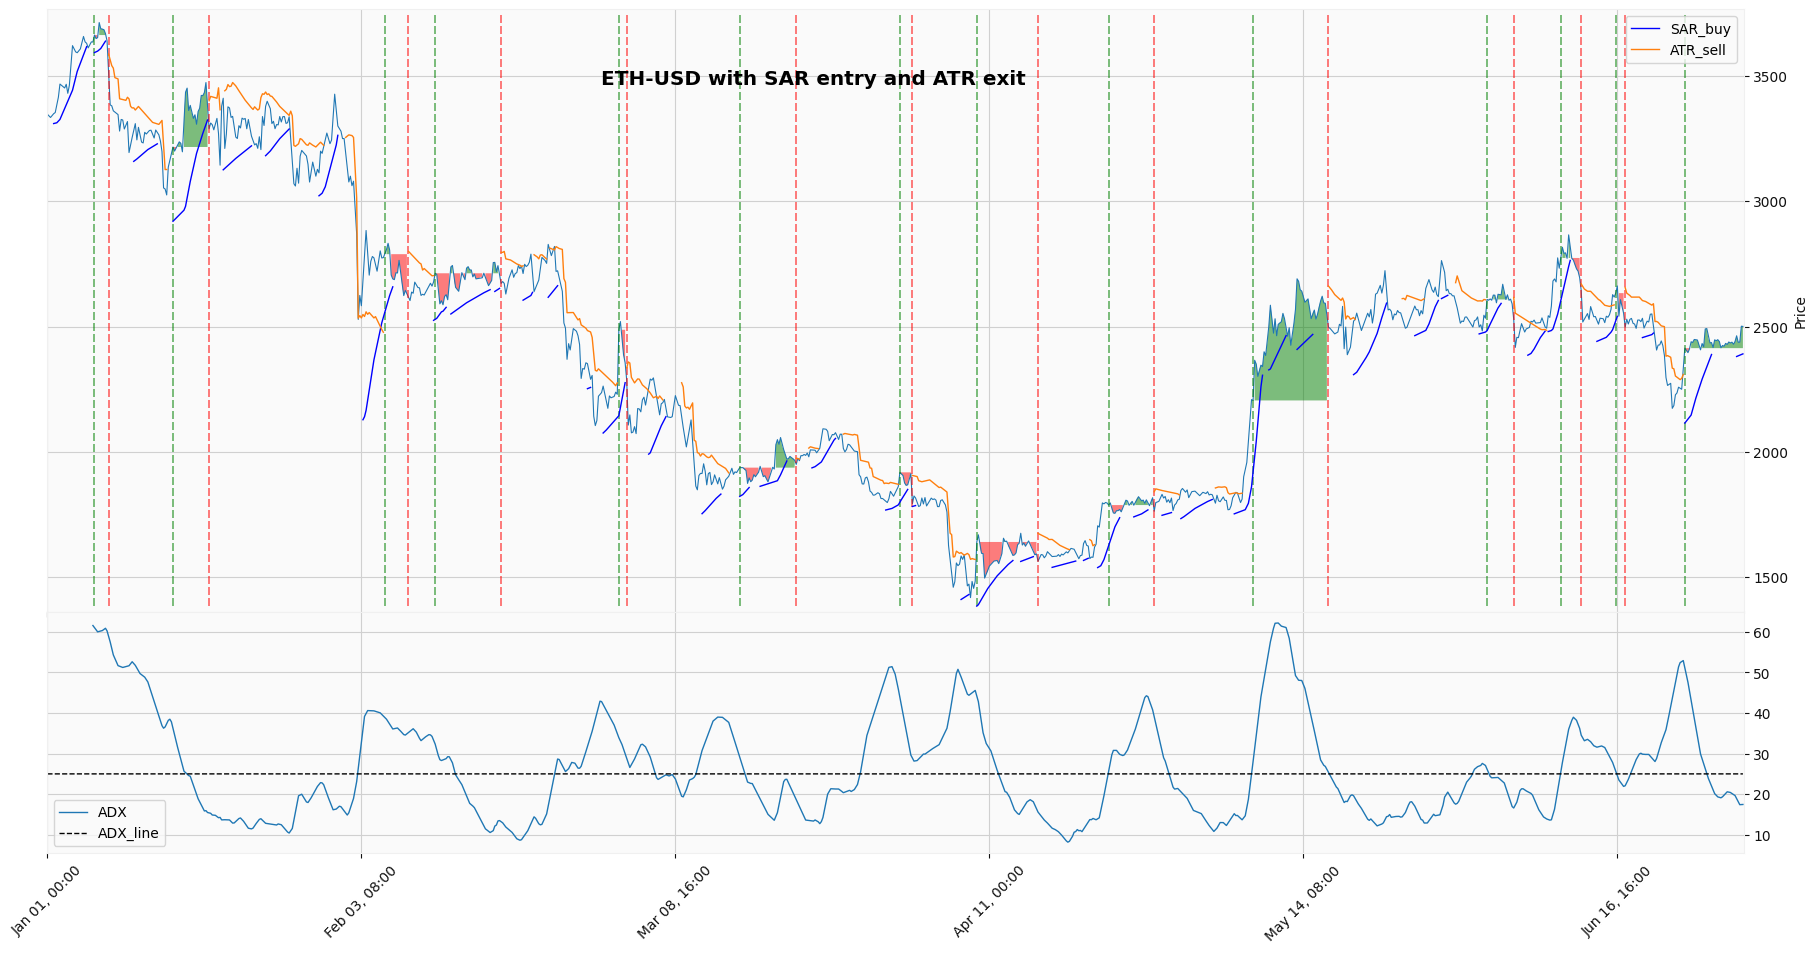

In [207]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)

addplots = [
    mpf.make_addplot(psar.iloc[:, 0], type='line', color='blue', width=1.0, label='SAR_buy'),
    # mpf.make_addplot(psar.iloc[:, 1], type='line', color='orange', width=1.0, label='SAR_sell'),
    # mpf.make_addplot(signals['ce_l'], type='line', linestyle='--', width=1.0, label='ATR_buy',
    #                  secondary_y=False),
    mpf.make_addplot(signals['ce_sh'], type='line',  width=1.0, label='ATR_sell',
                     secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', width=1.0, label='ADX', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=False,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,
)
